In [1]:
# Parameters
# Refer to injected parameters for any run.ipynb (similar cell below)
fname = 'BY4741_FKS1-HS1_single_ortho_none'

In [2]:
# Parameters
fname = "BY4741_FKS1-HS3_single_ortho_none"


# Notebook to generate heatmaps

## Import libraries

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['svg.fonttype'] = 'none'

## Specify paths

In [4]:
variantdata_path = 'dimsum_output/variant_data/'
processed_data_outpath = 'processed_data/'
aggdata_outpath = 'aggregated_data/'
heatmapdata_outpath = 'heatmaps_data/'
mgraph_outpath = 'manuscript_figures/'

## Get conditions from filename

In [5]:
f = variantdata_path + fname
pos_offset = {'FKS1-HS1': 639,
              'FKS1-HS2': 1353,
              'FKS1-HS3': 690,
              'FKS2-HS1': 659,
              'FKS2-HS2': 1372
             }

In [6]:
cset = f.split('/')[-1].split('_') # Extract conditions from parameter
cset_name = '_'.join(cset) # Basename based on conditions
strain, locus, pool_type, compound = [cset[i] for i in (0,1,2,-1)]
print(f'Strain: {strain}')
print(f'Locus: {locus}')
print(f'Pool type: {pool_type}')
print(f'Compound: {compound}')

Strain: BY4741
Locus: FKS1-HS3
Pool type: single
Compound: none


In [7]:
if compound == 'none':
    thresh = -.7
    cax_label = 'del'
else:
    # Retrieve threshold value that classifies variants as resistant
    thresh_df = pd.read_csv(f"{aggdata_outpath}/classified_variants/{'_'.join(cset[:3])}/thresholds.csv", index_col=0)
    thresh = thresh_df.loc[(thresh_df.compound == compound) & (thresh_df.thresh == 'low'), 'val'].item()
    cax_label = 'res'

## Import dataframe

In [8]:
withSyndf = pd.read_csv(processed_data_outpath+cset_name+'/selcoeff_all_libraries.csv', index_col=0)
wtaa = withSyndf.loc[withSyndf.WT == True, 'aa_seq'].values[0]
withSyndf

,seq_type,nt_seq,aa_pos,alt_codons,mutated_codon,aa_seq,WT,STOP,STOP_readthrough,Nham_nt,...,b1_log10,b2_log10,b3_log10,alt_aa,mutation_type,Log2FC_1,Log2FC_2,selcoeff_1,selcoeff_2,median_s
0,single,aatgatacctacttatggtacattattgtgaat,0.0,aat,1.0,NDTYLWYIIVN,NaN,False,False,3.0,...,-3.361767,-3.209790,-3.157363,N,non-synonymous,-0.183303,-0.101655,-0.195501,-0.106940,-0.151220
1,single,acggatacctacttatggtacattattgtgaat,0.0,acg,1.0,TDTYLWYIIVN,NaN,False,False,2.0,...,-1.935638,-1.911873,-1.916167,T,non-synonymous,-0.007481,0.031040,-0.019679,0.025756,0.003038
2,single,agggatacctacttatggtacattattgtgaat,0.0,agg,1.0,RDTYLWYIIVN,NaN,False,False,2.0,...,-4.893246,-5.517286,-5.491817,R,non-synonymous,-0.267373,-0.556567,-0.279571,-0.561852,-0.420711
3,single,agtgatacctacttatggtacattattgtgaat,0.0,agt,1.0,SDTYLWYIIVN,NaN,False,False,3.0,...,-2.786036,-2.776134,-2.795460,S,non-synonymous,-0.008891,0.013793,-0.021089,0.008508,-0.006290
4,single,atggatacctacttatggtacattattgtgaat,0.0,atg,1.0,MDTYLWYIIVN,NaN,False,False,1.0,...,-2.702914,-2.740584,-2.604762,M,non-synonymous,0.033354,-0.017455,0.021156,-0.022739,-0.000792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,WT,ttggatacctacttatggtacattattgtgaat,6.0,tac,NaN,LDTYLWYIIVN,True,NaN,NaN,NaN,...,NaN,NaN,NaN,Y,synonymous,0.039247,0.038517,0.027048,0.033233,0.030140
700,WT,ttggatacctacttatggtacattattgtgaat,7.0,att,NaN,LDTYLWYIIVN,True,NaN,NaN,NaN,...,NaN,NaN,NaN,I,synonymous,0.039247,0.038517,0.027048,0.033233,0.030140
701,WT,ttggatacctacttatggtacattattgtgaat,8.0,att,NaN,LDTYLWYIIVN,True,NaN,NaN,NaN,...,NaN,NaN,NaN,I,synonymous,0.039247,0.038517,0.027048,0.033233,0.030140
702,WT,ttggatacctacttatggtacattattgtgaat,9.0,gtg,NaN,LDTYLWYIIVN,True,NaN,NaN,NaN,...,NaN,NaN,NaN,V,synonymous,0.039247,0.038517,0.027048,0.033233,0.030140


## Reshape dataframe

In [9]:
if pool_type == 'single':
    withWTdf = withSyndf[withSyndf.seq_type.isin(['WT','single'])]
else:
    withWTdf = withSyndf[withSyndf.Nham_aa <=1]
withWTdf

,seq_type,nt_seq,aa_pos,alt_codons,mutated_codon,aa_seq,WT,STOP,STOP_readthrough,Nham_nt,...,b1_log10,b2_log10,b3_log10,alt_aa,mutation_type,Log2FC_1,Log2FC_2,selcoeff_1,selcoeff_2,median_s
0,single,aatgatacctacttatggtacattattgtgaat,0.0,aat,1.0,NDTYLWYIIVN,NaN,False,False,3.0,...,-3.361767,-3.209790,-3.157363,N,non-synonymous,-0.183303,-0.101655,-0.195501,-0.106940,-0.151220
1,single,acggatacctacttatggtacattattgtgaat,0.0,acg,1.0,TDTYLWYIIVN,NaN,False,False,2.0,...,-1.935638,-1.911873,-1.916167,T,non-synonymous,-0.007481,0.031040,-0.019679,0.025756,0.003038
2,single,agggatacctacttatggtacattattgtgaat,0.0,agg,1.0,RDTYLWYIIVN,NaN,False,False,2.0,...,-4.893246,-5.517286,-5.491817,R,non-synonymous,-0.267373,-0.556567,-0.279571,-0.561852,-0.420711
3,single,agtgatacctacttatggtacattattgtgaat,0.0,agt,1.0,SDTYLWYIIVN,NaN,False,False,3.0,...,-2.786036,-2.776134,-2.795460,S,non-synonymous,-0.008891,0.013793,-0.021089,0.008508,-0.006290
4,single,atggatacctacttatggtacattattgtgaat,0.0,atg,1.0,MDTYLWYIIVN,NaN,False,False,1.0,...,-2.702914,-2.740584,-2.604762,M,non-synonymous,0.033354,-0.017455,0.021156,-0.022739,-0.000792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,WT,ttggatacctacttatggtacattattgtgaat,6.0,tac,NaN,LDTYLWYIIVN,True,NaN,NaN,NaN,...,NaN,NaN,NaN,Y,synonymous,0.039247,0.038517,0.027048,0.033233,0.030140
700,WT,ttggatacctacttatggtacattattgtgaat,7.0,att,NaN,LDTYLWYIIVN,True,NaN,NaN,NaN,...,NaN,NaN,NaN,I,synonymous,0.039247,0.038517,0.027048,0.033233,0.030140
701,WT,ttggatacctacttatggtacattattgtgaat,8.0,att,NaN,LDTYLWYIIVN,True,NaN,NaN,NaN,...,NaN,NaN,NaN,I,synonymous,0.039247,0.038517,0.027048,0.033233,0.030140
702,WT,ttggatacctacttatggtacattattgtgaat,9.0,gtg,NaN,LDTYLWYIIVN,True,NaN,NaN,NaN,...,NaN,NaN,NaN,V,synonymous,0.039247,0.038517,0.027048,0.033233,0.030140


### Import validation mutants missing from the dataset (only for BY FKS1-HS1)

In [10]:
rescued_df = pd.read_csv(f'{aggdata_outpath}/validation_DMS_missing_estimates.csv', index_col=0)[['genotype','compound','estimated_s']]
rescued_df.head(8)

,genotype,compound,estimated_s
8,F639C,anidulafungin,1.392582
9,F639C,caspofungin,1.329652
10,F639C,micafungin,1.345690
11,F639C,none,0.084872
32,L640D,anidulafungin,-0.007735
33,L640D,caspofungin,-0.053246
34,L640D,micafungin,0.489734
35,L640D,none,0.041897


### Pivot dataframe

In [11]:
withWTdf_gby = withWTdf.groupby(['alt_aa','aa_pos','nt_seq'])[['median_s','confidence_score']].first().reset_index()

In [12]:
aa_single = withWTdf_gby.groupby(['alt_aa','aa_pos'])[['median_s','confidence_score']].agg(median_s = ('median_s', 'median'),
                                                                                           cscore = ('confidence_score', 'min')
                                                                                          ).reset_index()
aa_single['aa_pos'] = aa_single['aa_pos'].astype(int) + pos_offset[locus]

In [13]:
aa_single

,alt_aa,aa_pos,median_s,cscore
0,*,690,-0.190121,1.0
1,*,691,-0.241916,1.0
2,*,692,-0.172219,1.0
3,*,693,0.017068,3.0
4,*,694,-0.163812,1.0
...,...,...,...,...
209,Y,696,-0.058174,1.0
210,Y,697,0.000692,1.0
211,Y,698,0.001913,1.0
212,Y,699,-0.018201,1.0


In [14]:
if (strain == 'BY4741') & (locus == 'FKS1-HS1'):
    rescued_filtered = rescued_df[(rescued_df.compound == compound)
                                  & (rescued_df.genotype.isin(['F639C', 'L640D', 'L642G', 'P647N', 'P647Q']))
                                 ]
    rescued_filtered['wt_aa'], rescued_filtered['aa_pos'], rescued_filtered['alt_aa'] = zip(*rescued_filtered['genotype'].apply(lambda x: [x[0], int(x[1:-1]), x[-1]]))
    rescued_filtered.rename(columns={'estimated_s':'median_s'}, inplace=True)
else:
    rescued_filtered = pd.DataFrame([], columns=['alt_aa','aa_pos','median_s'])

In [15]:
aa_single_complete = pd.concat([aa_single[aa_single.cscore < 3], rescued_filtered[['alt_aa','aa_pos','median_s']]], ignore_index=True)
aa_single_complete.to_csv(f'{heatmapdata_outpath}/{cset_name}.csv')
aa_single_complete

/tmp/ipykernel_2250/3264132531.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  aa_single_complete = pd.concat([aa_single[aa_single.cscore < 3], rescued_filtered[['alt_aa','aa_pos','median_s']]], ignore_index=True)


,alt_aa,aa_pos,median_s,cscore
0,*,690,-0.190121,1.0
1,*,691,-0.241916,1.0
2,*,692,-0.172219,1.0
3,*,694,-0.163812,1.0
4,*,695,-0.022403,2.0
...,...,...,...,...
201,Y,696,-0.058174,1.0
202,Y,697,0.000692,1.0
203,Y,698,0.001913,1.0
204,Y,699,-0.018201,1.0


In [16]:
wide_aa = aa_single_complete.pivot(index='alt_aa', columns='aa_pos', values='median_s')

aa_sort_order = '*PGCQNTSEDKHRWYFMLIVA'
aa_sort_dic = dict(zip(list(aa_sort_order), list(range(0,len(aa_sort_order)))))
wide_aa.sort_index(key=lambda x: x.map(aa_sort_dic), inplace=True)
wide_aa

aa_pos,690,691,692,693,694,695,696,697,698,699,700
alt_aa,,,,,,,,,,,
*,-0.190121,-0.241916,-0.172219,NaN,-0.163812,-0.022403,-0.242846,-0.342260,-0.234296,-0.198959,0.036133
P,0.040119,-0.515045,-0.192443,0.024153,NaN,-0.028990,-0.296934,-0.226757,-0.513013,-0.174003,-0.222210
G,NaN,-0.888249,-0.012358,-0.102574,-0.258184,-0.008333,0.034939,0.021512,NaN,0.018113,-0.129011
C,-0.019854,-0.012690,-0.285925,-0.009356,-0.023179,-0.070525,-0.022403,0.024845,-0.001780,0.011601,NaN
Q,-0.272631,-0.015577,0.000971,-0.010485,0.033560,-0.436885,-0.381142,0.009357,NaN,-0.014789,0.042722
N,-0.151220,0.025138,NaN,-0.369010,-0.041494,NaN,0.007214,0.100876,0.014252,0.033835,0.030140
T,0.003038,-0.052534,0.019876,-0.228066,-0.027169,-0.041169,0.046833,0.031706,0.022928,0.007575,0.048858
S,-0.006290,-0.569451,0.035754,0.036006,-0.007099,0.014351,0.050955,0.069165,0.011723,0.031649,0.041925
E,0.013253,0.050797,-0.030063,NaN,-0.011905,-0.536256,-0.017835,0.035193,0.015267,0.051530,0.107198


## Draw heatmap

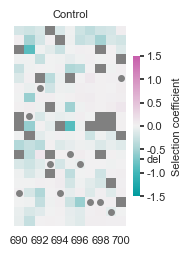

In [17]:
from matplotlib.ticker import MultipleLocator

# Convert conditions to title labels
title_dict = {'none':'Control',
              'dox':'Doxycycline control\n(Paralog repressed)',
              'anidulafungin':'Anidulafungin',
              'caspofungin':'Caspofungin',
              'micafungin':'Micafungin'
             }

# Purge graph space
sns.set(rc = {'figure.figsize':(1.8, 2.6),
              'font.size':8,
              'legend.title_fontsize':8, 'legend.fontsize':8,
              'axes.labelsize':8,'axes.titlesize':8,
              'xtick.labelsize':8, 'ytick.labelsize':8,
             },
       style='whitegrid')
f, ax = plt.subplots()

# Custom color palette
ccmap = sns.color_palette("blend:#009B9E,#42B7B9,#A7D3D4,#F1F1F1,#E4C1D9,#D691C1,#C75DAB", # CARTOColors Tropic
                          as_cmap=True)
ccmap.set_bad('.5') # Color for missing values

# Mask for missing values
mask = pd.isnull(wide_aa)

# Draw heatmap
ax = sns.heatmap(wide_aa, mask=mask, 
                 cmap=ccmap,
                 vmin=-1.5, center=0, vmax=1.5,
                 #xticklabels=len(wtaa)-1,
                 xticklabels=2,
                 yticklabels=False,
                 cbar_kws={'label':'Selection coefficient',
                           'shrink':.7
                          }
                )

ax.set_title(title_dict[compound])
ax.set(xlabel=None, ylabel=None)
ax.tick_params(axis='x', length=3)

cax = ax.figure.axes[-1]
cax.set_yticks([x for x in cax.get_yticks()]+[thresh], labels=[x for x in cax.get_yticks()]+[cax_label])
cax.tick_params(length=3, pad=2)

# Coordinates of WT protein sequence on the heatmap are extracted from the dataframe
# Coordinates should be OK even if the dataframe contains missing values
wtcoord_aa = [(i+0.5, list(aa_sort_order).index(v)+0.5) for i,v in enumerate(wtaa)]

for o in wtcoord_aa:
    ax.plot(o[0],o[1], marker='o', color='.5', markersize=4) # displays WT sequence

# Variants for which we inferred the DMS score
#estimate_coord = [(a+0.75-pos_offset[locus], list(aa_sort_order).index(b)+0.25) for a, b in zip(rescued_filtered.aa_pos, rescued_filtered.alt_aa)]

#for m in estimate_coord:
#    ax.plot(m[0],m[1], marker='*', color='.5', markersize=2)

# Graphs are output in the specified folder
plt.savefig(mgraph_outpath+cset_name+'_aa_heatmap_median_s.svg', format='svg', dpi=300)